# Visualisasi Tahapan Pengolahan Citra

Notebook ini menampilkan visualisasi setiap tahap preprocessing yang digunakan dalam klasifikasi koin.

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Setup
BASE_DIR = Path('..').resolve()
DATASET_DIR = BASE_DIR / 'dataset_splitted'
OUTPUT_DIR = BASE_DIR / 'results' / 'preprocessing_visualization'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Load sample image
sample_path = DATASET_DIR / "Koin Rp 500" / "angka" / "IMG_E2952.JPG"
img_original = cv2.imread(str(sample_path))
img_resized = cv2.resize(img_original, (256, 256))
print(f"Loaded: {sample_path.name}")

Loaded: IMG_E2952.JPG


## 1. CLAHE (Contrast Limited Adaptive Histogram Equalization)

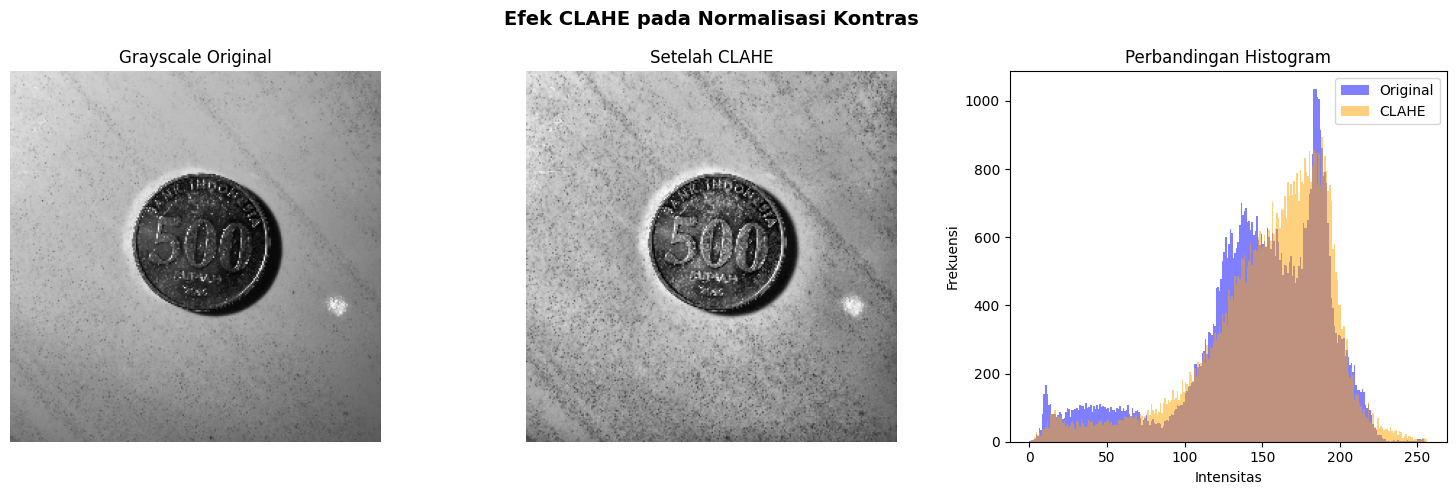

In [8]:
def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    if len(image.shape) == 3:
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge([l_clahe, a, b])
        result = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
    else:
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        result = clahe.apply(image)
    return result

# Apply CLAHE
gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
gray_clahe = apply_clahe(gray)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale Original', fontsize=12)
axes[0].axis('off')

axes[1].imshow(gray_clahe, cmap='gray')
axes[1].set_title('Setelah CLAHE', fontsize=12)
axes[1].axis('off')

# Histogram comparison
axes[2].hist(gray.ravel(), bins=256, range=(0, 256), alpha=0.5, label='Original', color='blue')
axes[2].hist(gray_clahe.ravel(), bins=256, range=(0, 256), alpha=0.5, label='CLAHE', color='orange')
axes[2].set_title('Perbandingan Histogram', fontsize=12)
axes[2].legend()
axes[2].set_xlabel('Intensitas')
axes[2].set_ylabel('Frekuensi')

plt.suptitle('Efek CLAHE pada Normalisasi Kontras', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '1_clahe_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Perbandingan Canny vs Sobel Edge Detection

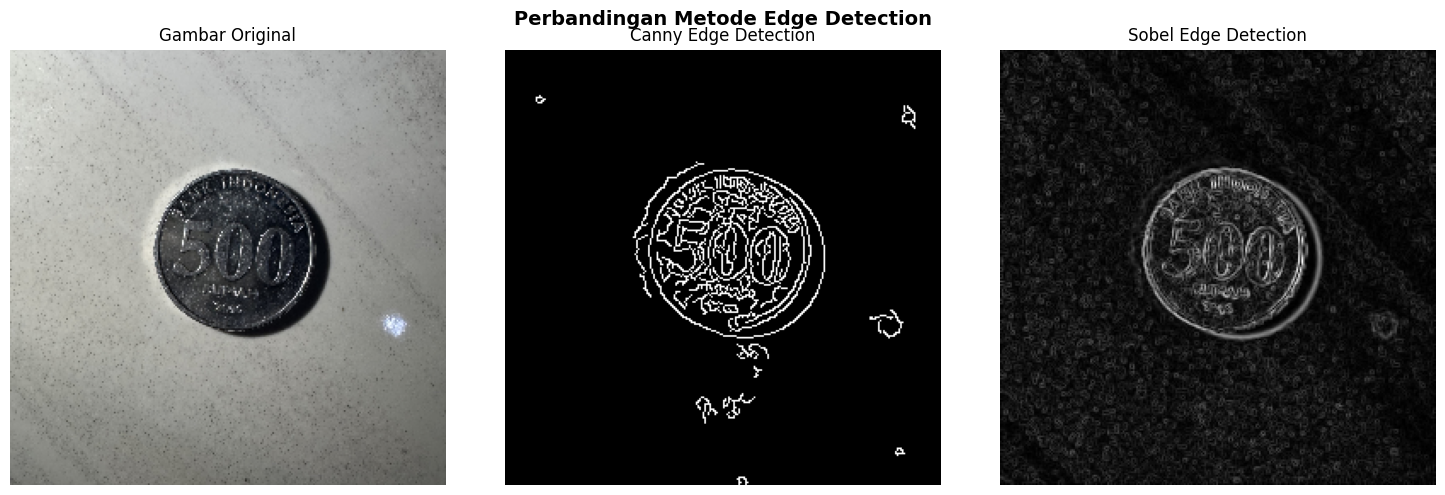

In [9]:
def apply_canny(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    gray = apply_clahe(gray)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)
    return edges

def apply_sobel(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    gray = apply_clahe(gray)
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel_combined = np.uint8(sobel_combined / sobel_combined.max() * 255)
    return sobel_combined

# Apply edge detection
edges_canny = apply_canny(img_resized)
edges_sobel = apply_sobel(img_resized)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
axes[0].set_title('Gambar Original', fontsize=12)
axes[0].axis('off')

axes[1].imshow(edges_canny, cmap='gray')
axes[1].set_title('Canny Edge Detection', fontsize=12)
axes[1].axis('off')

axes[2].imshow(edges_sobel, cmap='gray')
axes[2].set_title('Sobel Edge Detection', fontsize=12)
axes[2].axis('off')

plt.suptitle('Perbandingan Metode Edge Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '2_edge_detection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Hough Circle Transform

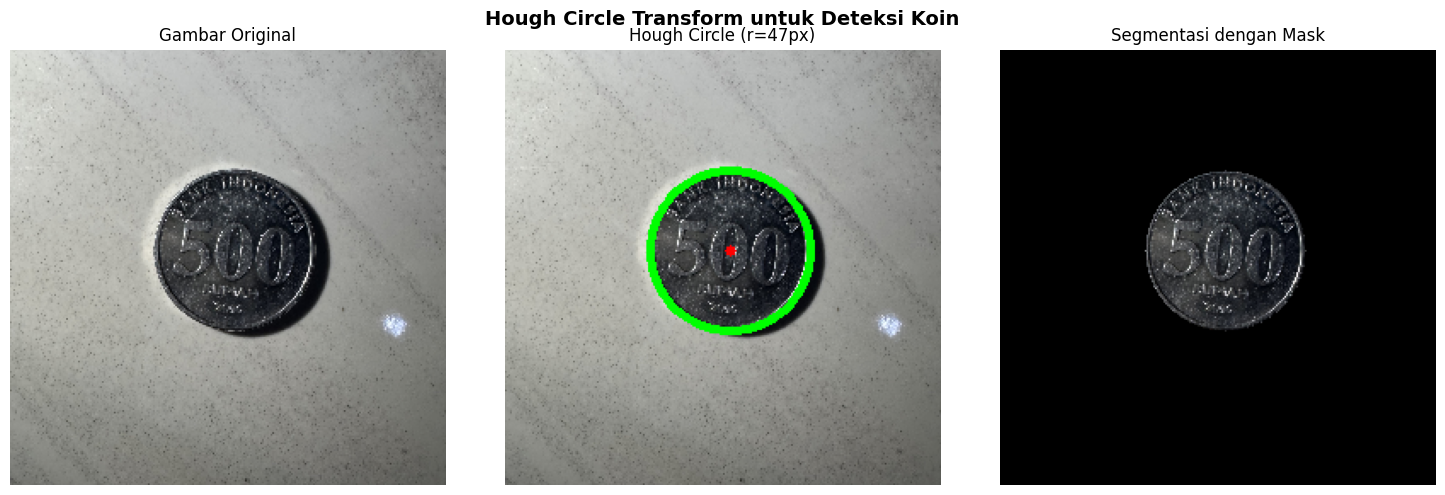

In [10]:
def detect_circle(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    gray_blurred = cv2.GaussianBlur(gray, (9, 9), 2)
    
    circles = cv2.HoughCircles(
        gray_blurred,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=50,
        param1=100,
        param2=30,
        minRadius=20,
        maxRadius=200
    )
    return circles

# Detect circle
circles = detect_circle(img_resized)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
axes[0].set_title('Gambar Original', fontsize=12)
axes[0].axis('off')

# Draw circle
img_with_circle = img_resized.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    x, y, r = circles[0, 0]
    cv2.circle(img_with_circle, (x, y), r, (0, 255, 0), 3)
    cv2.circle(img_with_circle, (x, y), 3, (0, 0, 255), -1)

axes[1].imshow(cv2.cvtColor(img_with_circle, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Hough Circle (r={r}px)', fontsize=12)
axes[1].axis('off')

# Create mask
mask = np.zeros(img_resized.shape[:2], dtype=np.uint8)
cv2.circle(mask, (x, y), r, 255, -1)
segmented = cv2.bitwise_and(img_resized, img_resized, mask=mask)

axes[2].imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
axes[2].set_title('Segmentasi dengan Mask', fontsize=12)
axes[2].axis('off')

plt.suptitle('Hough Circle Transform untuk Deteksi Koin', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '3_hough_circle.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Cropping ke Diameter Lingkaran

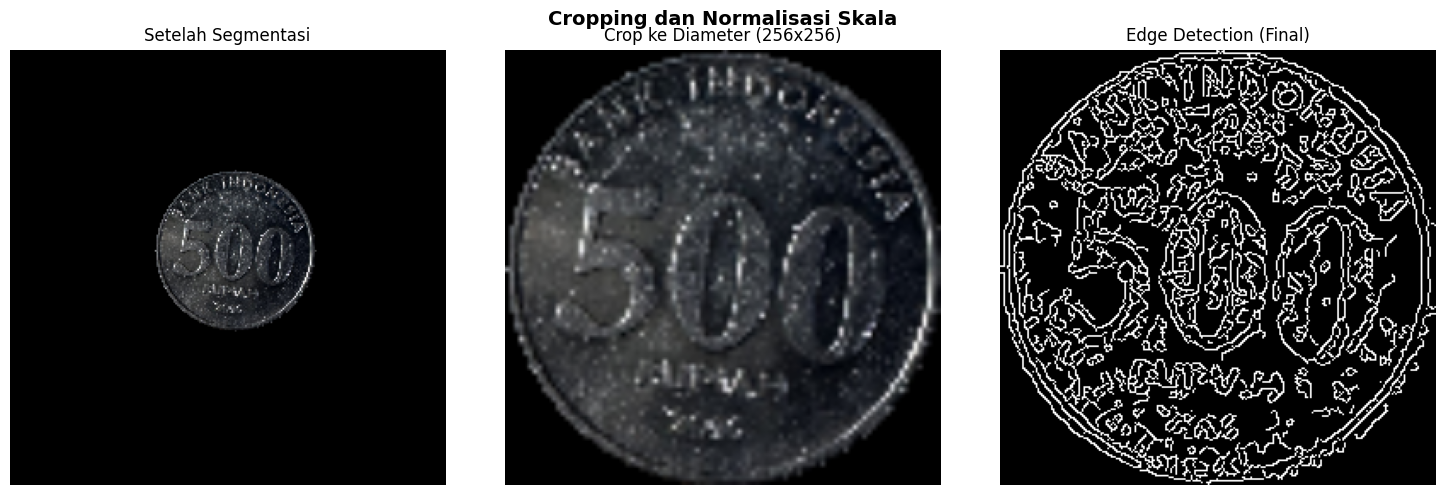

In [11]:
def crop_to_circle(image, circle_info, target_size=(256, 256)):
    x, y, r = circle_info
    h, w = image.shape[:2]
    
    # Calculate crop region
    x1 = max(0, x - r)
    y1 = max(0, y - r)
    x2 = min(w, x + r)
    y2 = min(h, y + r)
    
    cropped = image[y1:y2, x1:x2]
    resized = cv2.resize(cropped, target_size)
    return resized

# Crop and resize
cropped = crop_to_circle(segmented, (x, y, r))
edges_cropped = apply_canny(cropped)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
axes[0].set_title('Setelah Segmentasi', fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
axes[1].set_title('Crop ke Diameter (256x256)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(edges_cropped, cmap='gray')
axes[2].set_title('Edge Detection (Final)', fontsize=12)
axes[2].axis('off')

plt.suptitle('Cropping dan Normalisasi Skala', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '4_cropping.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Pipeline Lengkap - Beberapa Sampel

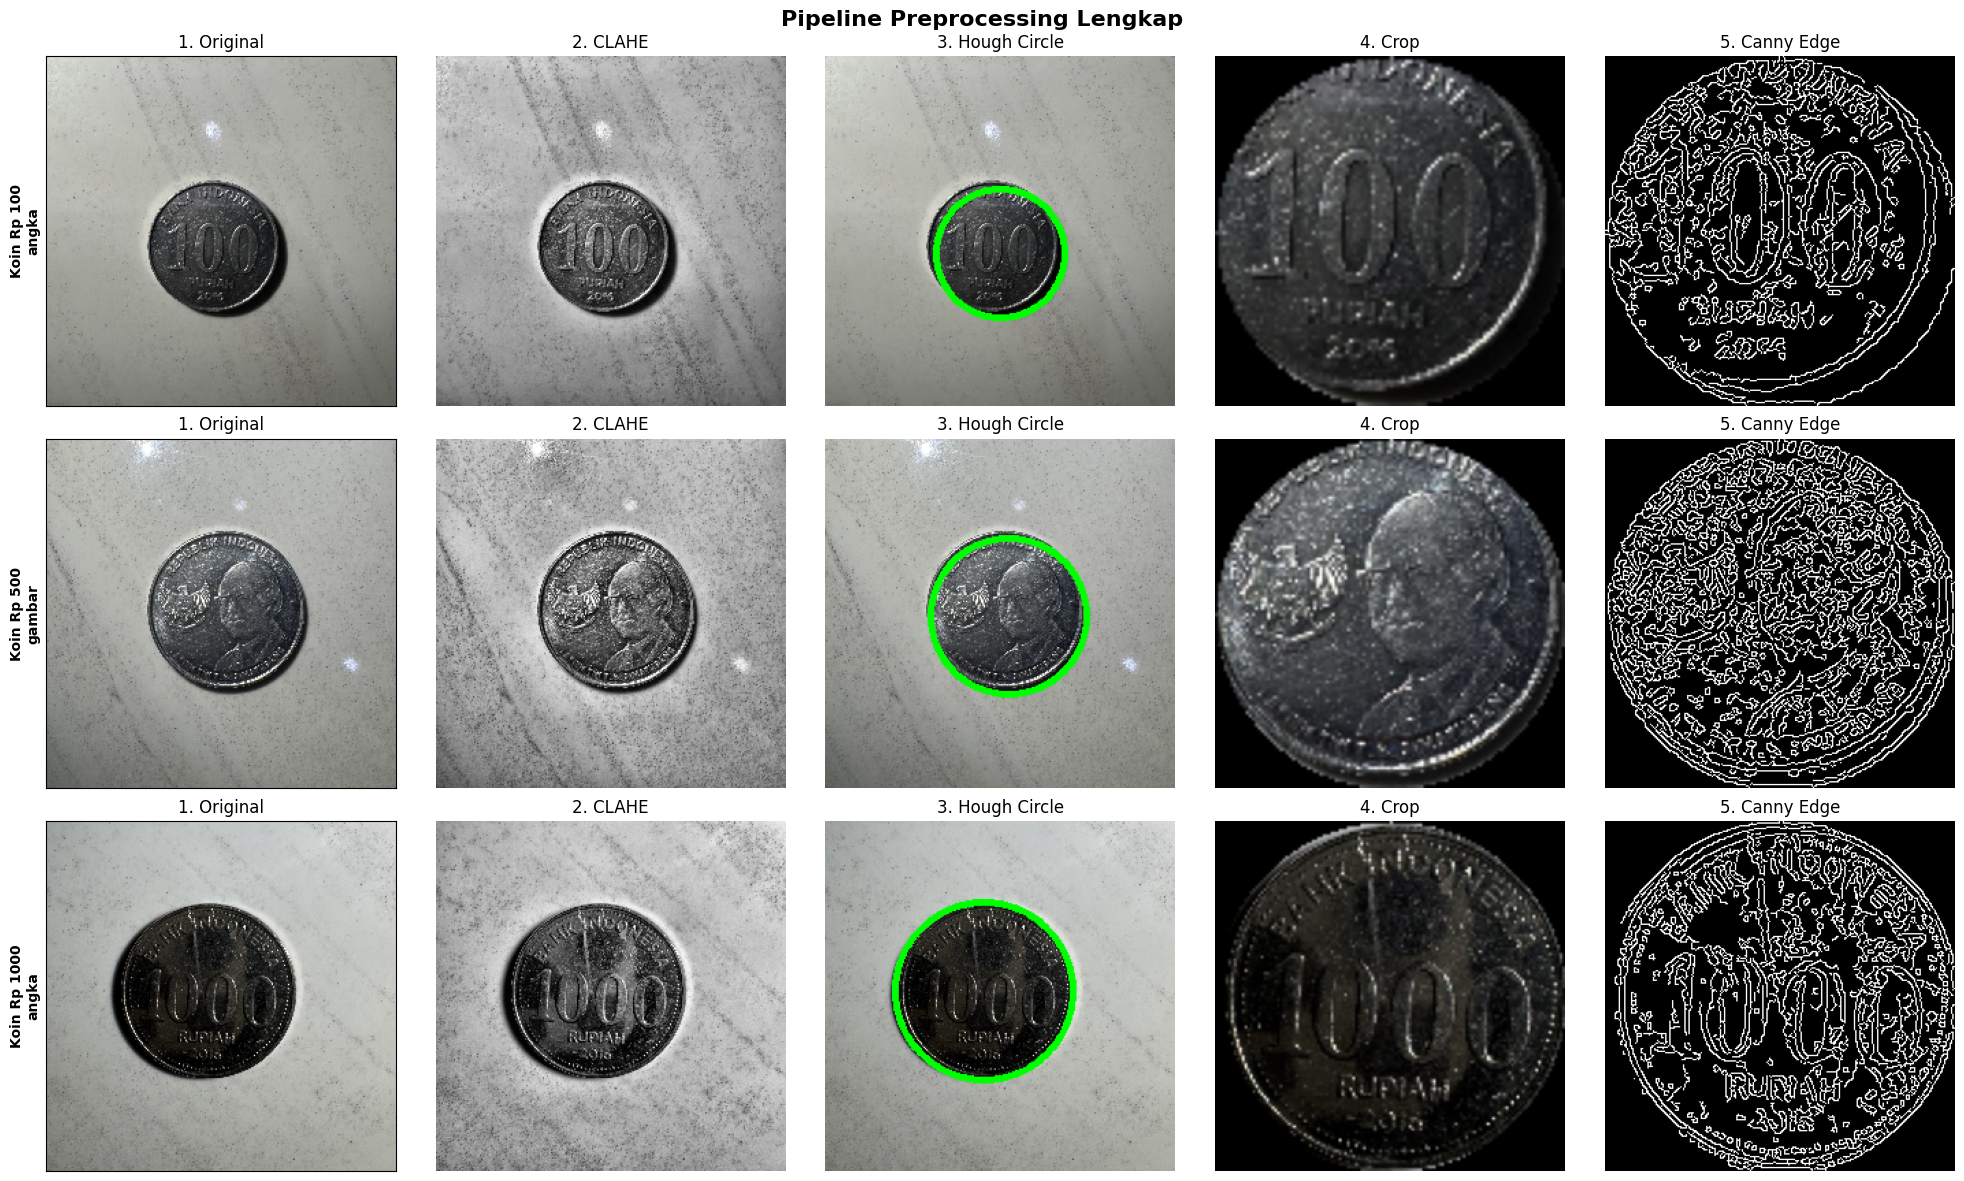

In [12]:
# Load multiple samples
samples = [
    ('Koin Rp 100', 'angka'),
    ('Koin Rp 500', 'gambar'),
    ('Koin Rp 1000', 'angka'),
]

fig, axes = plt.subplots(len(samples), 5, figsize=(20, 4*len(samples)))

for idx, (coin_type, side) in enumerate(samples):
    # Load image
    sample_dir = DATASET_DIR / coin_type / side
    images = list(sample_dir.glob('*.JPG'))
    img = cv2.imread(str(images[0]))
    img = cv2.resize(img, (256, 256))
    
    # Process
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_clahe = apply_clahe(gray)
    edges = apply_canny(img)
    
    circles = detect_circle(img)
    if circles is not None:
        circles = np.uint16(np.around(circles))
        x, y, r = circles[0, 0]
        
        img_circle = img.copy()
        cv2.circle(img_circle, (x, y), r, (0, 255, 0), 3)
        
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        cv2.circle(mask, (x, y), r, 255, -1)
        segmented = cv2.bitwise_and(img, img, mask=mask)
        cropped = crop_to_circle(segmented, (x, y, r))
        edges_final = apply_canny(cropped)
    
    # Plot
    axes[idx, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[idx, 0].set_title('1. Original')
    axes[idx, 0].set_ylabel(f'{coin_type}\n{side}', fontsize=10, fontweight='bold')
    axes[idx, 0].set_xticks([]); axes[idx, 0].set_yticks([])
    
    axes[idx, 1].imshow(gray_clahe, cmap='gray')
    axes[idx, 1].set_title('2. CLAHE')
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(cv2.cvtColor(img_circle, cv2.COLOR_BGR2RGB))
    axes[idx, 2].set_title('3. Hough Circle')
    axes[idx, 2].axis('off')
    
    axes[idx, 3].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    axes[idx, 3].set_title('4. Crop')
    axes[idx, 3].axis('off')
    
    axes[idx, 4].imshow(edges_final, cmap='gray')
    axes[idx, 4].set_title('5. Canny Edge')
    axes[idx, 4].axis('off')

plt.suptitle('Pipeline Preprocessing Lengkap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '5_full_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Perbandingan: Dengan vs Tanpa Preprocessing

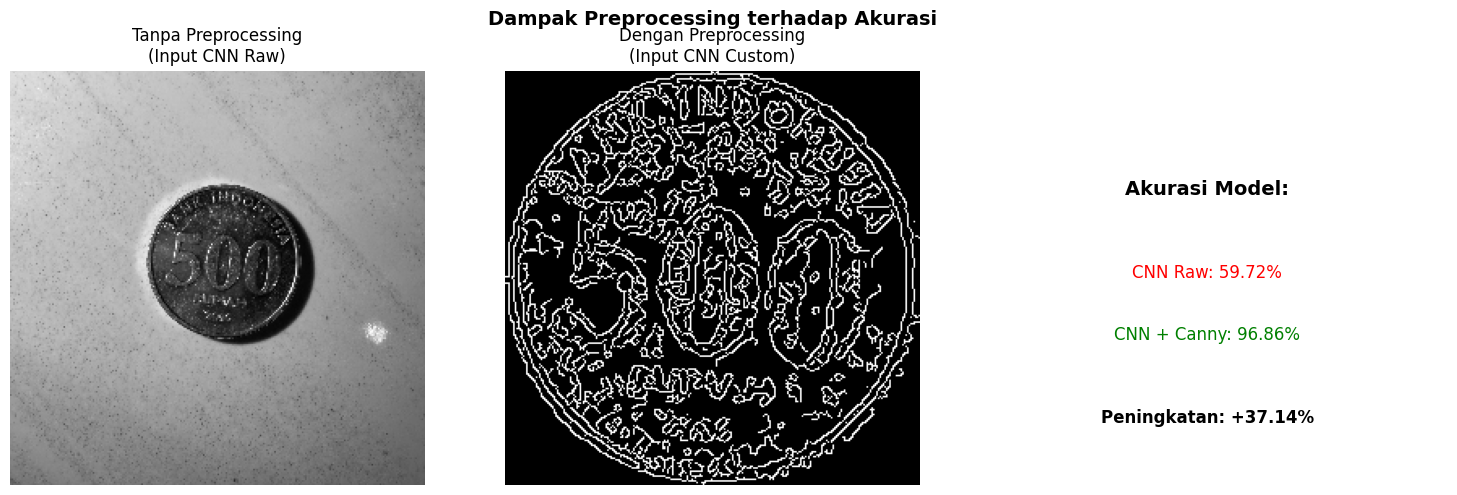


Semua visualisasi tersimpan di: D:\dev\semester5\pengolahan-citra\projek-edge-detection\results\preprocessing_visualization


In [13]:
# Visualize difference
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Raw grayscale (tanpa preprocessing)
raw_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
raw_normalized = raw_gray.astype(np.float32) / 255.0

axes[0].imshow(raw_gray, cmap='gray')
axes[0].set_title('Tanpa Preprocessing\n(Input CNN Raw)', fontsize=12)
axes[0].axis('off')

# With preprocessing (edge detection)
axes[1].imshow(edges_cropped, cmap='gray')
axes[1].set_title('Dengan Preprocessing\n(Input CNN Custom)', fontsize=12)
axes[1].axis('off')

# Comparison text
axes[2].text(0.5, 0.7, 'Akurasi Model:', fontsize=14, fontweight='bold', 
             ha='center', transform=axes[2].transAxes)
axes[2].text(0.5, 0.5, 'CNN Raw: 59.72%', fontsize=12, color='red',
             ha='center', transform=axes[2].transAxes)
axes[2].text(0.5, 0.35, 'CNN + Canny: 96.86%', fontsize=12, color='green',
             ha='center', transform=axes[2].transAxes)
axes[2].text(0.5, 0.15, 'Peningkatan: +37.14%', fontsize=12, fontweight='bold',
             ha='center', transform=axes[2].transAxes)
axes[2].axis('off')

plt.suptitle('Dampak Preprocessing terhadap Akurasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '6_preprocessing_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSemua visualisasi tersimpan di:", OUTPUT_DIR)